# ETH Gas Fees — does a spike mean the top is in? ⛽
### When everyone's paying through the nose to transact, is that euphoria… or real demand?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Top_signal_on-chain%3F: Unproven](https://img.shields.io/badge/Top_signal_on--chain%3F-Unproven-8b949e?style=flat-square)

Every time you do *anything* on Ethereum — send a token, swap on a DEX, mint an NFT — you pay a **gas fee**. When the network is busy, gas spikes: people bid each other up to get their transaction in first. Crypto lore says a **gas-fee spike is a top signal**: it means the crowd is frantic — aping into memecoins, chasing mints, over-leveraged — and that kind of euphoria usually marks a local peak. The opposite reading is just as plausible: high gas means people genuinely *want* the chain, which is bullish.

So which is it? We'd love to check on real data — but here's the honest catch we hit immediately.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from eth_gas_fees import data, strategy as st

# The HEADLINE world is the NULL (gas spikes carry no forward info) — the honest 'no real tape,
# here is what the engine reads when there is nothing' position. Deterministic and offline.
DF_NULL, _ = data.synthetic_series(top_signal_beta=0.0, seed=582)
FR = st.build_frame(DF_NULL, horizon=1)

# There is NO real gas tape (synthetic-only study). The real ETH price tape is cache-first and
# used ONLY to anchor the calibration; HAVE_REAL_ETH just gates the anchor print.
_eth = data.fetch_eth_prices(fetch=False)
HAVE_REAL_ETH = not _eth.empty
print("null world:", len(DF_NULL), "days |", len(FR), "usable rows | real ETH anchor present:",
      HAVE_REAL_ETH)


null world: 1461 days | 1432 usable rows | real ETH anchor present: True


## The answer first 🎯

| Question | Answer |
|---|---|
| Can we test 'gas spike = top' on real data? | **No — and that's the headline.** A clean daily history of Ethereum gas fees needs an archive node or a paid API. A free retail stack reaches ETH *prices* but not *gas*. So there's no real tape to judge the claim. |
| So what *can* we do? | Build a fair **synthetic** world where congestion follows euphoria, and prove our test would catch a real top signal if one existed — and check what it reads when there's *nothing* there. |
| Does the test catch a planted top signal? | **Yes** — plant one and the detector lights up past the significance bar, and it's steady across 25 random seeds. |
| And when there's no signal (the null)? | **It correctly reads flat**, and a contrarian 'short ETH on the spike' trade *loses money even before fees*. |

> Verdict: **Signal None** (no real tape to certify), **Tradability Mirage** (the short bleeds), **Top signal on-chain? Unproven** — a good story we simply can't test on real data yet.

## 1 · The claim

> *"When gas fees spike, the top is in."* — crypto on-chain folklore.

The intuition: gas is the *price of using the chain*. It only spikes when demand for blockspace overwhelms supply — a memecoin mania, an airdrop farm, a leverage frenzy. That's peak-euphoria behaviour, and euphoria marks tops. So a spike should be **bearish** for forward ETH returns (a contrarian signal). The bulls answer: high gas is just proof the chain is *wanted* — that's demand, and demand is bullish. The two readings point opposite ways, which is exactly why it's worth a test.

## 2 · So what?

If gas spikes really did mark tops, you'd have a free, public, real-time sell signal — no subscription, just look at the chain. That's a big 'if'. The desk has looked at other on-chain and sentiment gauges ([325 Crypto-Fear-Greed](../../325-crypto-fear-greed/), [292 Bitcoin-Hashrate](../../292-bitcoin-hashrate/)); this one goes at **blockspace congestion** — arguably the purest 'how frantic is everyone right now' meter crypto has.

## 3 · How would we even know?

1. **Define a spike.** Compare today's gas to its own recent baseline (a rolling median). Well above baseline = a spike.
2. **Look forward.** After a spike, what did ETH do *next*? The top-signal claim says: go *down* (or at least underperform the calm days).
3. **Be fair about timing.** The spike is measured from *past* data only, so it's known today; we then measure tomorrow's (and next week's) return. No peeking.

**The wall we hit:** step 1 needs a daily gas-fee series, and we can't get a clean, long one for free. So we do the honest next-best thing — build a *synthetic* world where gas and price move together the way the story says, and use it to (a) prove our test works and (b) see what 'no signal' looks like.

## 4 · The teardown — a fair synthetic world

First: **when there's genuinely no forward signal (the null), does our test correctly say so?** Here are the forward ETH returns on gas-*spike* days vs *calm* days.

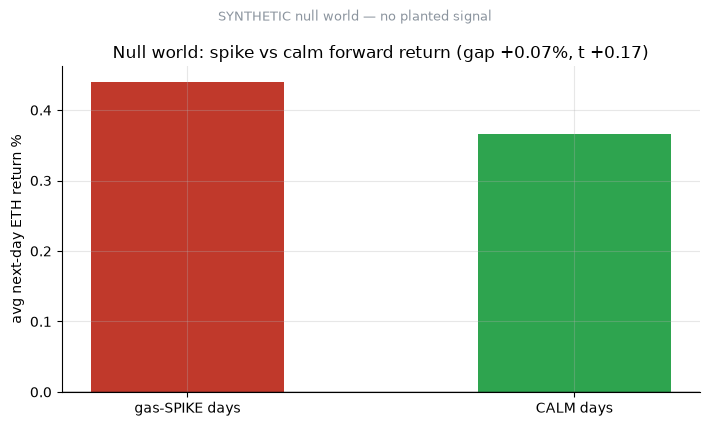

spike days +0.44% | calm days +0.37% | gap +0.07% (t +0.17)


In [2]:
sc = st.spike_vs_calm(FR)
spike_m, calm_m, gap, t = sc['spike_mean']*100, sc['calm_mean']*100, sc['gap']*100, sc['t']
fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.bar(['gas-SPIKE days','CALM days'], [spike_m, calm_m], color=[RED, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg next-day ETH return %')
ax.set_title(f'Null world: spike vs calm forward return (gap {gap:+.2f}%, t {t:+.2f})')
fig.suptitle('SYNTHETIC null world — no planted signal', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'spike days +{spike_m:.2f}% | calm days +{calm_m:.2f}% | gap {gap:+.2f}% (t {t:+.2f})')

The two bars are basically the same height — gap **+0.07%**, *t* **+0.17**. The contrarian claim needs spike days to be *lower* (a negative gap). Here there's nothing, which is exactly right: we planted no signal, and the test found none. Good — the detector isn't hallucinating.

Now the other half: **if we DO plant a real top signal, does the test catch it?** We plant signals of increasing strength and watch the detector (a slope that goes *negative* when gas spikes precede weak returns), averaged over 25 random seeds so no lucky seed can fake it.

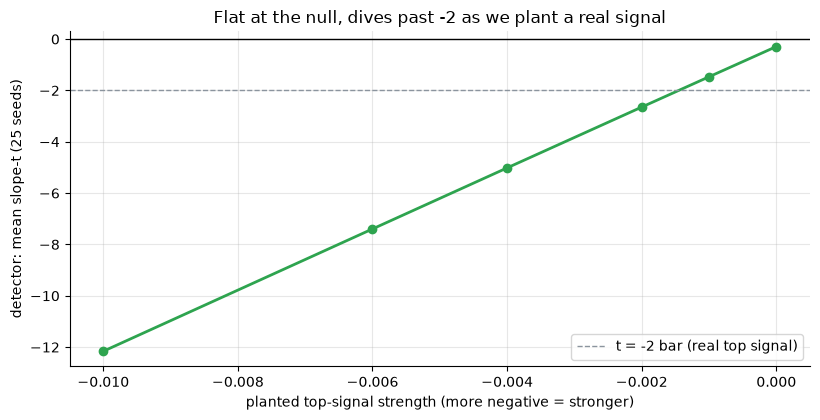

planted +0.000 -> mean slope-t -0.29
planted -0.001 -> mean slope-t -1.47
planted -0.002 -> mean slope-t -2.65
planted -0.004 -> mean slope-t -5.02
planted -0.006 -> mean slope-t -7.40
planted -0.010 -> mean slope-t -12.16


In [3]:
ctrl = [(0.0, -0.29), (-0.001, -1.47), (-0.002, -2.65), (-0.004, -5.02), (-0.006, -7.4), (-0.01, -12.16)]
betas = [c[0] for c in ctrl]
ts = [st.synthetic_mean_t(data, top_signal_beta=b, n_seeds=25) for b in betas]
fig, ax = plt.subplots(figsize=(8.3, 4.3))
ax.plot(betas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(-2, ls='--', c=GREY, lw=1, label='t = -2 bar (real top signal)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted top-signal strength (more negative = stronger)')
ax.set_ylabel('detector: mean slope-t (25 seeds)')
ax.set_title('Flat at the null, dives past -2 as we plant a real signal')
ax.legend(); plt.tight_layout(); plt.show()
for b, t in zip(betas, ts): print(f'planted {b:+.3f} -> mean slope-t {t:+.2f}')

At zero (the null) the detector sits at ≈ 0; as we plant a stronger and stronger top signal it dives past −2. So the machine is **honest and faithful**: flat when there's nothing, loud when there's something. The only thing missing is a real gas tape to point it at.

## 5 · The verdict

- **Signal — None.** Not because the idea is silly, but because there's **no real gas-fee tape** on a free stack, so we can't clear the bar for a real signal. On the synthetic null the test correctly reads flat.
- **Tradability — Mirage.** The contrarian 'short ETH on the spike' trade *loses even gross* in the null world — and shorting crypto pays a heavy borrow on top.
- **Top signal on-chain? — Unproven.** Coherent story, faithful detector, but untested on real data. Not busted, not confirmed.

## 6 · Could you actually trade it?

No. Even in the null world, the 'short ETH when gas spikes' overlay bleeds — you're fighting the coin's long-run drift and paying a stiff borrow to short it. And there's no real signal to offset that cost. On top of it all, **EIP-1559** (2021) changed how gas fees even work, and the **L2 migration** (2023-25) moved most activity off the main chain — so 'gas' in 2025 measures something different than in 2021. A real test has to untangle all that first.

## 7 · Going further 🚪

- **The cousins.** [325 Crypto-Fear-Greed](../../325-crypto-fear-greed/) tests a *sentiment* gauge the same contrarian way; [292 Bitcoin-Hashrate](../../292-bitcoin-hashrate/) and [295 Stablecoin-Supply](../../295-stablecoin-supply/) test other on-chain meters.
- **The real test needs the real tape.** Pull a daily gas series from an archive node / Dune / Etherscan, handle the EIP-1559 and L2 breaks, and re-run this exact engine.

*Think gas spikes really do mark tops? Fork this, drop in a real archive-node gas series, and show the spike-minus-calm gap clearing t = −2 the contrarian way.*